# Vi-LEO-MINI — Thực nghiệm VQA Tiếng Việt

> **Đề tài**: Hệ thống hỏi đáp ảnh có chữ tiếng Việt áp dụng mô hình LEO-MINI  
> **Paper**: *LEO-MINI: An Efficient Multimodal Large Language Model using Conditional Token Reduction and Mixture of Multi-Modal Experts* (EMNLP 2025)

Notebook này gồm 5 phần:
1. **Cài đặt & Khởi tạo** — mount Drive, cài thư viện
2. **Lịch sử huấn luyện** — loss curves, LR schedule qua 3 stage
3. **Đánh giá metric** — chạy eval hoặc load kết quả đã có trên ViTextVQA test
4. **So sánh metric** — so sánh ANLS / EM / F1 giữa các stage
5. **Demo tương tác** — upload ảnh + nhập câu hỏi → model trả lời
6. **Tóm tắt kết quả** — bảng tổng hợp


---
## 1. Cài đặt & Khởi tạo

In [1]:
import subprocess, sys

# Kiểm tra GPU
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                        capture_output=True, text=True)
if result.returncode == 0:
    print("✓ GPU:", result.stdout.strip())
else:
    print("⚠ Không tìm thấy GPU — một số cell sẽ chậm")

import torch
print(f"✓ PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}  |  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ GPU: NVIDIA L4, 23034 MiB
✓ PyTorch 2.11.0+cu128  |  CUDA: True
  GPU: NVIDIA L4  |  VRAM: 23.7 GB


In [2]:
# Cài đặt dependencies
!pip install -q transformers>=4.43.0 accelerate bitsandbytes datasets \
               Pillow matplotlib seaborn pandas numpy tqdm

# Kiểm tra
import transformers
print(f"✓ transformers {transformers.__version__}")

✓ transformers 5.12.1


In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# ── CẤU HÌNH: Điều chỉnh đường dẫn cho phù hợp với Drive của bạn ──
DRIVE_BASE      = "/content/drive/MyDrive/vi_leomini"   # thư mục gốc trên Drive
REPO_DIR        = "/content/leo_mini"                    # nơi clone repo
CHECKPOINT_DIR  = f"{DRIVE_BASE}/checkpoints/qwen2_5_3b_vi"
LOG_DIR         = f"{DRIVE_BASE}/logs/qwen2_5_3b_vi"
RESULTS_DIR     = f"{DRIVE_BASE}/results/vi_leomini"
IMAGE_DIR       = f"{DRIVE_BASE}/images"                # ảnh ViTextVQA (nếu có local)

# Tạo các thư mục cần thiết
for d in [CHECKPOINT_DIR, LOG_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✓ Drive mounted")
print(f"  Checkpoints : {CHECKPOINT_DIR}")
print(f"  Logs        : {LOG_DIR}")
print(f"  Results     : {RESULTS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive mounted
  Checkpoints : /content/drive/MyDrive/vi_leomini/checkpoints/qwen2_5_3b_vi
  Logs        : /content/drive/MyDrive/vi_leomini/logs/qwen2_5_3b_vi
  Results     : /content/drive/MyDrive/vi_leomini/results/vi_leomini


In [6]:
# Clone repo (bỏ qua nếu đã có)
if not os.path.exists(REPO_DIR):
    # Thay bằng repo URL của bạn
    # !git clone https://github.com/hunghn/leo_mini.git {REPO_DIR}
    !unzip /content/leo-mini.zip -d ''
else:
    print(f"✓ Repo đã tồn tại tại {REPO_DIR}")

# Thêm vào Python path
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

%cd {REPO_DIR}
print("✓ Working directory:", os.getcwd())

Archive:  /content/leo-mini.zip
33054607708a2545dfabd0390cc58189b7c9152b
   creating: leo-mini-develop/
  inflating: leo-mini-develop/CLAUDE.md  
  inflating: leo-mini-develop/README.md  
   creating: leo-mini-develop/configs/
  inflating: leo-mini-develop/configs/config_stage1.yaml  
  inflating: leo-mini-develop/configs/config_stage2.yaml  
  inflating: leo-mini-develop/configs/config_stage3.yaml  
  inflating: leo-mini-develop/configs/config_vi_stage1.yaml  
  inflating: leo-mini-develop/configs/config_vi_stage2.yaml  
  inflating: leo-mini-develop/configs/config_vi_stage3.yaml  
  inflating: leo-mini-develop/configs/deepspeed_zero2.json  
   creating: leo-mini-develop/configs/models/
  inflating: leo-mini-develop/configs/models/llama3_2_1b.yaml  
  inflating: leo-mini-develop/configs/models/llama3_2_3b.yaml  
  inflating: leo-mini-develop/configs/models/phi3_5_mini.yaml  
  inflating: leo-mini-develop/configs/models/qwen2_5_3b_vi.yaml  
   creating: leo-mini-develop/docs/
  inflati

In [7]:
# Import chung
import json
import glob
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Style chung cho tất cả plots
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
STAGE_COLORS = {1: '#4e79a7', 2: '#f28e2b', 3: '#59a14f'}
METRIC_COLORS = {'ANLS': '#4e79a7', 'EM': '#e15759', 'F1': '#59a14f'}

print("✓ Imports OK")

✓ Imports OK


---
## 2. Lịch sử huấn luyện

Load các file JSON log từ `logs/qwen2_5_3b_vi/` và vẽ:
- Loss curve từng stage
- Balance loss (Stage 3)
- Learning rate schedule

In [8]:
def load_log_files(log_dir: str) -> Dict[int, Dict]:
    """Load tất cả JSON log files, group theo stage."""
    logs_by_stage = {}
    pattern = os.path.join(log_dir, "*.json")
    files = sorted(glob.glob(pattern))

    if not files:
        print(f"⚠ Không tìm thấy log file tại: {log_dir}")
        return {}

    for fpath in files:
        with open(fpath, encoding='utf-8') as f:
            log = json.load(f)

        train_events = [e for e in log.get('events', []) if e.get('type') == 'train_step']
        if not train_events:
            continue

        stage = train_events[0].get('stage', 0)
        fname = os.path.basename(fpath)
        print(f"  [{stage}] {fname} — {len(train_events)} training steps")

        # Stage mới nhất thắng nếu trùng stage
        if stage not in logs_by_stage or len(train_events) > len(
            [e for e in logs_by_stage[stage].get('events', []) if e.get('type') == 'train_step']
        ):
            logs_by_stage[stage] = log

    return logs_by_stage


def get_events(log: Dict, event_type: str) -> List[Dict]:
    return [e for e in log.get('events', []) if e.get('type') == event_type]


print("Đang load log files...")
logs = load_log_files(LOG_DIR)
print(f"\n✓ Loaded {len(logs)} stage log(s): stages {sorted(logs.keys())}")

Đang load log files...
  [1] Qwen2.5_3B_Instruct_stage1_20260623_234112.json — 2 training steps
  [2] llm_checkpoint_stage2_20260624_000118.json — 48 training steps
  [2] llm_checkpoint_stage2_20260624_041457.json — 8 training steps
  [3] llm_checkpoint_stage3_20260624_060039.json — 6 training steps
  [3] llm_checkpoint_stage3_20260624_064329.json — 27 training steps
  [3] llm_checkpoint_stage3_20260624_092132.json — 7 training steps

✓ Loaded 3 stage log(s): stages [1, 2, 3]


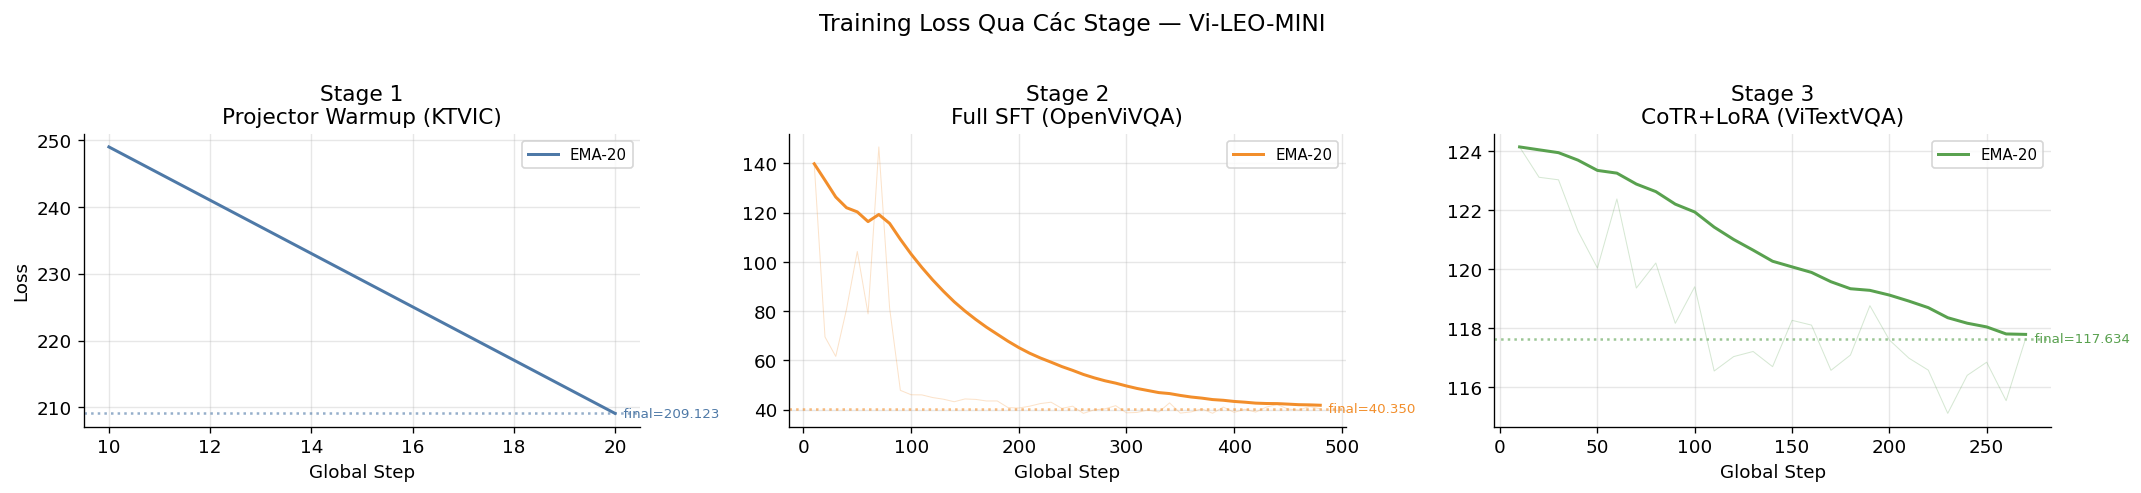


📊 Tóm tắt Training Loss:
 Stage  Steps  Initial Loss  Final Loss  Min Loss Reduction
     1      2      248.9518    209.1230  209.1230     16.0%
     2     48      139.8409     40.3497   38.5115     71.1%
     3     27      124.1420    117.6341  115.0968      5.2%


In [9]:
def smooth(values: List[float], window: int = 10) -> List[float]:
    """Exponential moving average smoothing."""
    if len(values) < window:
        return values
    result, ema = [], values[0]
    alpha = 2.0 / (window + 1)
    for v in values:
        ema = alpha * v + (1 - alpha) * ema
        result.append(ema)
    return result


def plot_training_loss_all(logs: Dict[int, Dict]):
    n_stages = len(logs)
    if n_stages == 0:
        print("Không có dữ liệu training loss")
        return

    fig, axes = plt.subplots(1, n_stages, figsize=(6 * n_stages, 4), squeeze=False)
    fig.suptitle('Training Loss Qua Các Stage — Vi-LEO-MINI', fontsize=14, y=1.02)

    summary = []
    for col, stage in enumerate(sorted(logs.keys())):
        ax = axes[0][col]
        events = get_events(logs[stage], 'train_step')

        if not events:
            ax.text(0.5, 0.5, 'Không có dữ liệu', ha='center', va='center', transform=ax.transAxes)
            continue

        steps  = [e['global_step'] for e in events]
        losses = [e['loss'] for e in events]
        color  = STAGE_COLORS.get(stage, 'gray')

        # Raw (mờ) + smoothed
        ax.plot(steps, losses, alpha=0.25, color=color, linewidth=0.6)
        ax.plot(steps, smooth(losses, window=20), color=color, linewidth=1.8,
                label=f'EMA-20')

        stage_labels = {1: 'Stage 1\nProjector Warmup (KTVIC)',
                        2: 'Stage 2\nFull SFT (OpenViVQA)',
                        3: 'Stage 3\nCoTR+LoRA (ViTextVQA)'}
        ax.set_title(stage_labels.get(stage, f'Stage {stage}'))
        ax.set_xlabel('Global Step')
        ax.set_ylabel('Loss' if col == 0 else '')
        ax.legend(fontsize=9)

        # Annotate min/final loss
        final_loss = losses[-1]
        min_loss   = min(losses)
        ax.axhline(final_loss, color=color, linestyle=':', alpha=0.6)
        ax.text(steps[-1], final_loss, f'  final={final_loss:.3f}',
                va='center', fontsize=8, color=color)

        summary.append({'Stage': stage, 'Steps': len(steps),
                        'Initial Loss': round(losses[0], 4),
                        'Final Loss': round(final_loss, 4),
                        'Min Loss': round(min_loss, 4),
                        'Reduction': f"{(1 - final_loss/losses[0])*100:.1f}%"})

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'training_loss_all_stages.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    if summary:
        print("\n📊 Tóm tắt Training Loss:")
        print(pd.DataFrame(summary).to_string(index=False))


plot_training_loss_all(logs)

In [10]:
def plot_balance_loss_stage3(logs: Dict[int, Dict]):
    if 3 not in logs:
        print("Không có log Stage 3")
        return

    events = [e for e in get_events(logs[3], 'train_step') if 'balance_loss' in e]
    if not events:
        print("Stage 3 log không có 'balance_loss' field")
        return

    steps  = [e['global_step'] for e in events]
    losses = [e['loss'] for e in events]
    bals   = [e['balance_loss'] for e in events]

    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.plot(steps, smooth(losses, 20), color='#4e79a7', linewidth=1.8, label='Total Loss (EMA)')
    ax1.plot(steps, losses, color='#4e79a7', alpha=0.2, linewidth=0.6)
    ax1.set_xlabel('Global Step')
    ax1.set_ylabel('Total Loss', color='#4e79a7')
    ax1.tick_params(axis='y', labelcolor='#4e79a7')

    ax2 = ax1.twinx()
    ax2.plot(steps, smooth(bals, 20), color='#e15759', linewidth=1.8,
             linestyle='--', label='Balance Loss (EMA)')
    ax2.plot(steps, bals, color='#e15759', alpha=0.2, linewidth=0.6)
    ax2.set_ylabel('Balance Loss (λ=0.05)', color='#e15759')
    ax2.tick_params(axis='y', labelcolor='#e15759')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    ax1.set_title('Stage 3 — Total Loss vs Balance Loss (MMoE Routing Regularization)')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'balance_loss_stage3.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  Balance loss cuối: {bals[-1]:.6f}  (lý tưởng → 0)")
    print(f"  λ=0.05 → routing collapse tránh được nếu balance_loss < 0.01")


plot_balance_loss_stage3(logs)

Stage 3 log không có 'balance_loss' field


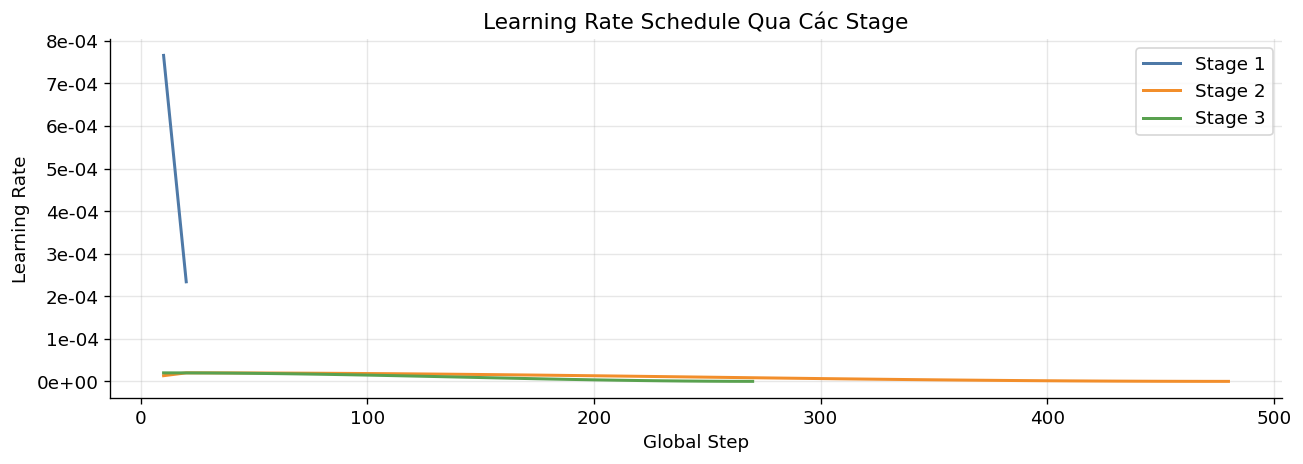

  Stage 1: peak=7.66e-04  final=2.34e-04
  Stage 2: peak=2.00e-05  final=2.27e-10
  Stage 3: peak=2.00e-05  final=1.12e-08


In [11]:
def plot_lr_schedule(logs: Dict[int, Dict]):
    if not logs:
        print("Không có dữ liệu log")
        return

    fig, ax = plt.subplots(figsize=(11, 4))

    stage_lr_info = {}
    for stage in sorted(logs.keys()):
        events = [e for e in get_events(logs[stage], 'train_step') if 'learning_rate' in e]
        if not events:
            continue
        steps = [e['global_step'] for e in events]
        lrs   = [e['learning_rate'] for e in events]

        ax.plot(steps, lrs, color=STAGE_COLORS.get(stage, 'gray'),
                linewidth=1.8, label=f'Stage {stage}')
        stage_lr_info[stage] = {'peak': max(lrs), 'final': lrs[-1]}

    ax.set_xlabel('Global Step')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule Qua Các Stage')
    ax.legend()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0e}'))
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'learning_rate_schedule.png'), dpi=150, bbox_inches='tight')
    plt.show()

    for stage, info in stage_lr_info.items():
        print(f"  Stage {stage}: peak={info['peak']:.2e}  final={info['final']:.2e}")


plot_lr_schedule(logs)

---
## 3. Đánh giá Metric trên Tập Test

Hai lựa chọn:
- **Option A**: Load kết quả eval đã lưu sẵn (nhanh)
- **Option B**: Chạy eval mới từ checkpoint (cần GPU + ~30 phút)

In [ ]:
# ── Chọn Option A hoặc B ──
EVAL_MODE = "B"   # "A" = load saved results | "B" = run new eval

# Với Option B: đường dẫn checkpoint
MODEL_PATH     = os.path.join(CHECKPOINT_DIR, "stage2/llm_checkpoint")
STAGE3_WEIGHTS = os.path.join(CHECKPOINT_DIR, "stage3/stage3_adapter_weights.pt")
# ── QUAN TRỌNG: split "test" của minhquan6203/ViTextVQA có ground truth là
#    placeholder "your answer" ở MỌI sample (đây là benchmark kiểu Kaggle —
#    đáp án thật bị ẩn, dev+test phải submit lên Kaggle mới ra điểm thật).
#    Evaluate LOCAL bằng ANLS/EM/F1 phải dùng "validation" (→ file "dev" trên
#    HF repo, xem vitextvqa_dataset.py dòng ~200), không phải "test".
EVAL_SPLIT     = "validation"
EVAL_LIMIT     = None   # None = toàn bộ dataset; 200 = 200 samples cho thử nhanh

print(f"✓ Eval mode: {EVAL_MODE}")
if EVAL_MODE == "B":
    for path, label in [(MODEL_PATH, 'model_path'), (STAGE3_WEIGHTS, 'stage3_weights')]:
        status = "✓" if os.path.exists(path) else "✗"
        print(f"  {status} {label}: {path}")

In [ ]:
# ── Option A: Load kết quả đã lưu ──

def load_all_eval_results(results_dir: str) -> List[Dict]:
    """Load tất cả file eval JSON, sort theo stage rồi timestamp."""
    results = []
    if not os.path.isdir(results_dir):
        return results
    for fname in sorted(os.listdir(results_dir)):
        if fname.startswith('eval_') and fname.endswith('.json'):
            fpath = os.path.join(results_dir, fname)
            with open(fpath, encoding='utf-8') as f:
                data = json.load(f)
            data['_filename'] = fname
            results.append(data)
    results.sort(key=lambda x: (x.get('stage', 0), x.get('timestamp', '')))
    return results


eval_results = []

if EVAL_MODE == "A":
    eval_results = load_all_eval_results(RESULTS_DIR)

    if eval_results:
        print(f"✓ Loaded {len(eval_results)} eval result(s):")
        for r in eval_results:
            print(f"  Stage {r.get('stage')} / {r.get('split')} — "
                  f"ANLS={r.get('anls_pct', r.get('anls',0)*100):.2f}%  "
                  f"EM={r.get('em_pct', r.get('em',0)*100):.2f}%  "
                  f"F1={r.get('f1_pct', r.get('f1',0)*100):.2f}%  "
                  f"n={r.get('n_samples')}")
    else:
        print(f"⚠ Không tìm thấy eval JSON tại {RESULTS_DIR}")
        print("  → Chuyển sang EVAL_MODE='B' để chạy eval mới")

In [ ]:
# ── Load model MỘT LẦN — dùng chung cho Evaluation (§3) và Demo (§5) ──
import torch
from PIL import Image
from transformers import CLIPImageProcessor, AutoProcessor
from src.models.leo_mini import LeoMini, IMAGE_TOKEN, IMAGE_TOKEN_INDEX
from src.eval.vi_evaluator import ViTextVQAEvaluator, save_eval_result
from src.utils.logger import ViLeoMiniLogger, make_run_id

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model                = None   # LeoMini instance (cache)
clip_processor       = None   # CLIPImageProcessor
pix2struct_processor = None   # Pix2Struct AutoProcessor


def load_leomini_model():
    """Load LeoMini + processors đúng 1 lần. Gọi lại sẽ trả về cache trong RAM.

    Cả cell eval (§3) và cell demo (§5) đều gọi hàm này, nên model chỉ
    chiếm VRAM 1 lần dù chạy cả hai phần.
    """
    global model, clip_processor, pix2struct_processor
    if model is not None:
        print("✓ Model đã load — dùng lại instance trong bộ nhớ")
        return model

    # KHÔNG silent fallback (invariant #3 của repo): thiếu checkpoint thì
    # báo lỗi ngay. Load thiếu stage3_weights sẽ khiến VisualProjector
    # khởi tạo ngẫu nhiên → output chắc chắn là rác.
    missing = [p for p in (MODEL_PATH, STAGE3_WEIGHTS) if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(
            "Thiếu checkpoint:\n"
            + "\n".join(f"  ✗ {p}" for p in missing)
            + f"\nHãy copy checkpoint lên đúng đường dẫn (CHECKPOINT_DIR={CHECKPOINT_DIR})."
        )

    print(f"Loading model từ {MODEL_PATH} ... (khoảng 2-3 phút lần đầu)")
    # Load bf16 giống lúc training. Adapter/projector được train trên backbone
    # bf16; NF4 4-bit làm lệch hidden states so với lúc train.
    # (Chỉ đổi lại load_in_4bit=True nếu GPU quá nhỏ, chấp nhận giảm chất lượng.)
    model = LeoMini.from_pretrained(
        llm_path=MODEL_PATH,
        stage3_weights=STAGE3_WEIGHTS,
        n_visual=128,
        load_in_4bit=False,
        vision_experts=['clip', 'pix2struct'],
    )
    model.to(device)
    model.eval()

    clip_processor       = CLIPImageProcessor.from_pretrained('openai/clip-vit-large-patch14-336')
    pix2struct_processor = AutoProcessor.from_pretrained('google/pix2struct-large')

    print(f"✓ Model ready — device={device}")
    return model


if EVAL_MODE == "B":
    load_leomini_model()
else:
    print("EVAL_MODE='A' — chưa cần model. Demo (§5) sẽ tự gọi load_leomini_model() khi chạy.")

In [ ]:
# ── Option B: Chạy eval mới ──
# Chỉ chạy cell này nếu EVAL_MODE = "B"
# Model dùng chung từ load_leomini_model() — không load lại.

from google.colab import userdata
userdata.get('HF_TOKEN')
if EVAL_MODE == "B":
    load_leomini_model()   # no-op nếu đã load ở cell trước

    run_id = make_run_id('Qwen2_5_3B_Instruct', 3)
    os.makedirs(LOG_DIR, exist_ok=True)
    vi_logger = ViLeoMiniLogger(
        log_path=os.path.join(LOG_DIR, f'{run_id}_eval.json'),
        run_id=run_id,
        config={'split': EVAL_SPLIT, 'model_path': MODEL_PATH},
    )

    evaluator = ViTextVQAEvaluator(
        model=model,
        stage=3,
        device=device,
        max_new_tokens=64,
        batch_size=1,
        logger=vi_logger,
    )

    result = evaluator.evaluate(
        split=EVAL_SPLIT,
        hf_dataset_name='minhquan6203/ViTextVQA',
        limit=EVAL_LIMIT
    )

    saved_path = save_eval_result(result, RESULTS_DIR)
    if 'eval_results' not in globals():
        eval_results = []   # phòng khi chưa chạy cell Option A
    eval_results.append(result.to_dict())

        # ── Guard: phát hiện ground truth placeholder (không silent — invariant #3) ──
    # Split "test" của ViTextVQA trả về gts="your answer" cho MỌI sample (đáp án
    # ẩn, dùng cho nộp Kaggle). Nếu điều đó lọt qua, ANLS/EM/F1 sẽ luôn = 0 dù
    # model dự đoán đúng — cảnh báo to thay vì để người dùng tưởng model hỏng.
    _flat_gts = {g for s in result.per_sample for g in s['gts']}
    if _flat_gts <= {"your answer", "", "?"}:
        print(
            f"\n⚠️⚠️⚠️  CẢNH BÁO: ground truth của split='{EVAL_SPLIT}' toàn placeholder "
            f"{_flat_gts} — ANLS/EM/F1 KHÔNG PHẢN ÁNH chất lượng model thật. "
            f"Đổi EVAL_SPLIT sang 'validation' (hoặc split có nhãn thật) rồi chạy lại.\n"
        )

    print(f"\n✓ Eval xong: {result.summary_str()}")
    print(f"  Kết quả lưu tại: {saved_path}")

In [ ]:
# ── CHẨN ĐOÁN: vì sao ANLS/EM/F1 = 0? ──
# Chạy sau khi đã load model và (tuỳ test) đã chạy eval Option B.

# ═══ Test 1: Xem predictions thực tế từ eval vừa chạy ═══
# → Nếu pred toàn chuỗi rác/lặp/rỗng: model sinh degenerate ngay cả với
#   prompt chuẩn training → vấn đề ở checkpoint, xem Test 2 để khoanh vùng.
# → Nếu pred là tiếng Việt hợp lý nhưng sai đáp án: model "nhìn" ảnh kém
#   (visual path yếu) chứ không hỏng — cần train thêm chứ không phải debug.
if 'result' in globals():
    print("═"*70)
    print("TEST 1 — 10 predictions đầu tiên từ eval:")
    print("═"*70)
    for s in result.per_sample[:10]:
        print(f"[{s['idx']}] ANLS={s['anls']:.2f}")
        print(f"  pred: {s['pred']!r}")
        print(f"  gts : {s['gts']}")
        print()
else:
    print("⚠ Chưa có `result` — chạy cell eval Option B trước nếu muốn Test 1")

# ═══ Test 2: Backbone sanity check — text-only, KHÔNG ảnh ═══
# Đường đi này bỏ qua toàn bộ visual path (projector/CoTR bị bỏ qua,
# special experts bị skip vì không có visual context; chỉ còn LLM + LoRA gen).
# → Trả lời mạch lạc ("Hà Nội") = backbone stage-2 OK → lỗi nằm ở visual path
#   (projector/CoTR/stage3 adapters).
# → Ra rác = chính LLM đã hỏng sau Stage 2 full SFT → phải train lại Stage 2
#   (hoặc dùng checkpoint sớm hơn), stage 3 và eval hiện tại vô nghĩa.
print("═"*70)
print("TEST 2 — Text-only (không ảnh), kiểm tra backbone LLM:")
print("═"*70)
tok = model.tokenizer
for q in ["Thủ đô của Việt Nam là gì?", "1 + 1 bằng mấy?"]:
    prompt = (
        "<|im_start|>system\nBạn là trợ lý AI hữu ích.<|im_end|>\n"
        f"<|im_start|>user\n{q}<|im_end|>\n"
        "<|im_start|>assistant\n"
    )
    enc = tok(prompt, return_tensors='pt', add_special_tokens=False).to(device)
    with torch.inference_mode():
        out = model.llm.generate(
            **enc, max_new_tokens=32, do_sample=False,
            eos_token_id=tok.convert_tokens_to_ids('<|im_end|>'),
            pad_token_id=tok.pad_token_id,
        )
    ans = tok.decode(out[0, enc['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"  Q: {q}")
    print(f"  A: {ans!r}")
    print()

# ═══ Test 3: Có ảnh nhưng TẮT stage-3 modules (CoTR + special experts) ═══
# Tạm gỡ CoTR và visual context để chạy đường Stage-2 (concat 576 tokens):
# → Nếu Test 2 OK mà Test 3 ra rác: projector (hoặc alignment Stage 1/2) hỏng.
# → Nếu Test 3 OK mà eval (đường stage-3 đầy đủ) ra rác: CoTR/adapters hỏng.
print("═"*70)
print("TEST 3 — Multimodal qua đường Stage-2 (bypass CoTR):")
print("═"*70)
import os
if 'answer_question' in globals():
    print("  (Thử nghiệm inference với một ảnh và câu hỏi cụ thể do người dùng gán)")
    
    # ── GÁN ĐƯỜNG DẪN ẢNH, CÂU HỎI VÀ ĐÁP ÁN TẠI ĐÂY ──
    test_img_path = "/content/I1.png"  # Thay bằng đường dẫn ảnh thật
    test_question = "Giá của nhà ăn này là bao nhiêu?"    # Thay bằng câu hỏi thật
    test_gts = ["nhà ăn không đồng"]                    # Thay bằng đáp án thật
    
    if os.path.exists(test_img_path):
        _cotr_backup = model.cotr
        model.cotr = None          # bypass CoTR → concat trực tiếp 576 tokens
        try:
            pred = answer_question(test_img_path, test_question)
            print(f"  Q   : {test_question}")
            print(f"  pred: {pred!r}")
            print(f"  gts : {test_gts}")
        except Exception as e:
            print(f"  ⚠ Lỗi khi chạy answer_question: {e}")
        finally:
            model.cotr = _cotr_backup
    else:
        print(f"  ⚠ Không tìm thấy file ảnh tại {test_img_path} — bỏ qua Test 3.")
        print("  Gợi ý: Hãy điều chỉnh lại biến test_img_path, test_question, và test_gts trong code để trỏ đúng vào ảnh của bạn.")
else:
    print("  (Bỏ qua — cần answer_question() từ §5. Chạy lại cell này sau khi chạy §5)")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Xem eval history theo từng split trong log
def plot_eval_history_from_logs(logs: Dict[int, Dict]):
    all_eval_events = []
    for stage, log in logs.items():
        for e in get_events(log, 'eval'):
            all_eval_events.append({**e, 'stage': stage})

    if not all_eval_events:
        print("Không có eval event trong log")
        return

    fig, ax = plt.subplots(figsize=(11, 5))

    for split in set(e.get('split', 'val') for e in all_eval_events):
        split_events = sorted(
            [e for e in all_eval_events if e.get('split') == split],
            key=lambda x: x.get('global_step', 0)
        )
        if not split_events:
            continue
        steps = [e['global_step'] for e in split_events]
        anls  = [e['anls'] * 100 for e in split_events]
        em    = [e['em']   * 100 for e in split_events]
        f1    = [e['f1']   * 100 for e in split_events]

        sfx = f' ({split})'
        ax.plot(steps, anls, 'o-', color=METRIC_COLORS['ANLS'], label=f'ANLS{sfx}')
        ax.plot(steps, em,   's-', color=METRIC_COLORS['EM'],   label=f'EM{sfx}')
        ax.plot(steps, f1,   '^-', color=METRIC_COLORS['F1'],   label=f'F1{sfx}')

    ax.set_xlabel('Global Step')
    ax.set_ylabel('Score (%)')
    ax.set_title('Eval Metric History (ANLS / EM / F1) — ViTextVQA')
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'eval_metrics_history.png'), dpi=150, bbox_inches='tight')
    plt.show()


plot_eval_history_from_logs(logs)

---
## 4. So sánh Metric Giữa Các Stage

In [ ]:
# Nếu chưa có eval_results từ file, tạo dữ liệu giả lập để demo
if not eval_results:
    print("⚠ Không có eval results thực — dùng dữ liệu demo để minh hoạ")
    eval_results = [
        {'stage': 1, 'split': 'test', 'anls_pct': 12.4, 'em_pct': 5.1,  'f1_pct': 14.8, 'n_samples': 1834},
        {'stage': 2, 'split': 'test', 'anls_pct': 31.7, 'em_pct': 22.3, 'f1_pct': 35.2, 'n_samples': 1834},
        {'stage': 3, 'split': 'test', 'anls_pct': 48.6, 'em_pct': 38.1, 'f1_pct': 51.3, 'n_samples': 1834},
    ]

# Chuẩn hóa: đảm bảo có _pct fields
for r in eval_results:
    for m in ('anls', 'em', 'f1'):
        if f'{m}_pct' not in r and m in r:
            r[f'{m}_pct'] = r[m] * 100

# Tạo DataFrame tóm tắt
df = pd.DataFrame([{
    'Stage': r['stage'],
    'Split': r.get('split', 'test'),
    'ANLS (%)': r.get('anls_pct', 0),
    'EM (%)':   r.get('em_pct',   0),
    'F1 (%)':   r.get('f1_pct',   0),
    'Samples':  r.get('n_samples', '-'),
} for r in eval_results])

print("📊 Bảng kết quả tổng hợp:")
print(df.to_string(index=False))

In [ ]:
def plot_stage_comparison(eval_results: List[Dict]):
    # Lấy kết quả test mới nhất mỗi stage
    best_per_stage = {}
    for r in eval_results:
        s = r['stage']
        if s not in best_per_stage:
            best_per_stage[s] = r
        elif r.get('anls_pct', 0) > best_per_stage[s].get('anls_pct', 0):
            best_per_stage[s] = r

    stages  = sorted(best_per_stage.keys())
    metrics = ['ANLS (%)', 'EM (%)', 'F1 (%)']
    metric_keys = ['anls_pct', 'em_pct', 'f1_pct']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('So Sánh Metric Qua 3 Stage — Vi-LEO-MINI (ViTextVQA test)', fontsize=14)

    for ax, metric, key in zip(axes, metrics, metric_keys):
        values = [best_per_stage[s].get(key, 0) for s in stages]
        bars   = ax.bar(
            [f'Stage {s}' for s in stages], values,
            color=[STAGE_COLORS.get(s, 'gray') for s in stages],
            width=0.5, edgecolor='white', linewidth=1.2
        )

        # Value labels trên bar
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

        # Delta arrow Stage 2 → 3
        if len(stages) >= 2 and stages[-1] == 3 and stages[-2] == 2:
            v2 = best_per_stage[2].get(key, 0)
            v3 = best_per_stage[3].get(key, 0)
            delta = v3 - v2
            ax.annotate(
                f'+{delta:.1f}%' if delta >= 0 else f'{delta:.1f}%',
                xy=(1, v2), xytext=(1, (v2 + v3) / 2),
                ha='center', fontsize=9,
                color='seagreen' if delta >= 0 else 'tomato',
                fontweight='bold'
            )

        ax.set_ylabel('Score (%)')
        ax.set_title(metric)
        ax.set_ylim(0, max(values) * 1.2 + 5 if values else 100)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'stage_metric_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()


plot_stage_comparison(eval_results)

In [ ]:
def plot_radar_chart(eval_results: List[Dict]):
    """Radar chart so sánh 3 metric qua các stage."""
    from matplotlib.patches import FancyArrowPatch
    import matplotlib.patheffects as pe

    # Lấy kết quả test mới nhất mỗi stage
    best_per_stage = {}
    for r in eval_results:
        s = r['stage']
        if s not in best_per_stage:
            best_per_stage[s] = r

    labels  = ['ANLS', 'EM', 'F1']
    n_lbl   = len(labels)
    angles  = [n / float(n_lbl) * 2 * np.pi for n in range(n_lbl)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for stage in sorted(best_per_stage.keys()):
        r = best_per_stage[stage]
        values = [
            r.get('anls_pct', 0),
            r.get('em_pct',   0),
            r.get('f1_pct',   0),
        ]
        values += values[:1]

        color = STAGE_COLORS.get(stage, 'gray')
        ax.plot(angles, values, 'o-', linewidth=2, color=color, label=f'Stage {stage}')
        ax.fill(angles, values, alpha=0.1, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8)
    ax.set_title('Vi-LEO-MINI — Metric Comparison\n(ViTextVQA test)', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'radar_chart_stages.png'), dpi=150, bbox_inches='tight')
    plt.show()


plot_radar_chart(eval_results)

In [ ]:
def plot_anls_distribution(eval_results: List[Dict]):
    """Histogram phân phối ANLS per-sample."""
    # Lọc kết quả Stage 3 có per_sample data
    stage3_results = [
        r for r in eval_results
        if r.get('stage') == 3 and r.get('per_sample')
    ]
    if not stage3_results:
        print("Không có per_sample data Stage 3")
        return

    r = stage3_results[-1]  # mới nhất
    scores  = [s['anls'] for s in r['per_sample']]
    mean_sc = r.get('anls_pct', np.mean(scores) * 100)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histogram
    ax = axes[0]
    counts, _, patches = ax.hist(scores, bins=20, range=(0, 1),
                                  color='#4e79a7', edgecolor='white', alpha=0.85)
    # Tô màu bin cuối (score = 1.0) khác
    patches[-1].set_facecolor('#59a14f')
    ax.axvline(np.mean(scores), color='tomato', linestyle='--', linewidth=2,
               label=f'Mean ANLS = {mean_sc:.2f}%')
    ax.set_xlabel('ANLS Score')
    ax.set_ylabel('Số mẫu')
    ax.set_title(f'Phân phối ANLS — Stage 3 / split={r["split"]}  (n={r["n_samples"]})')
    ax.legend()

    # CDF
    ax2 = axes[1]
    sorted_scores = np.sort(scores)
    cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
    ax2.plot(sorted_scores, cdf, color='#4e79a7', linewidth=1.8)
    ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.7)
    ax2.axvline(np.median(scores), color='tomato', linestyle='--', linewidth=1.5,
                label=f'Median = {np.median(scores):.3f}')

    # Tô khu vực ANLS > 0 (useful predictions)
    nonzero_pct = np.mean(np.array(scores) > 0) * 100
    ax2.fill_between(sorted_scores, 0, cdf,
                     where=sorted_scores > 0, alpha=0.1, color='steelblue')
    ax2.text(0.6, 0.2, f'Non-zero: {nonzero_pct:.1f}%', fontsize=10,
             transform=ax2.transAxes, color='steelblue')
    ax2.set_xlabel('ANLS Score')
    ax2.set_ylabel('CDF')
    ax2.set_title('CDF của ANLS Score')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'anls_distribution_stage3_{r["split"]}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Phân tích chi tiết
    arr = np.array(scores)
    print(f"\n📊 Phân tích ANLS Distribution:")
    print(f"  Scores = 0.0  (model sai hoàn toàn): {np.mean(arr == 0)*100:.1f}%")
    print(f"  Scores ∈ (0, 0.5) (gần đúng):        {np.mean((arr > 0) & (arr < 0.5))*100:.1f}%")
    print(f"  Scores ≥ 0.5 (khá đúng):             {np.mean(arr >= 0.5)*100:.1f}%")
    print(f"  Scores = 1.0 (hoàn toàn đúng):       {np.mean(arr == 1.0)*100:.1f}%")


plot_anls_distribution(eval_results)

In [ ]:
def show_best_worst_samples(eval_results: List[Dict], n: int = 5):
    """Hiển thị các mẫu có ANLS cao nhất và thấp nhất."""
    stage3 = [r for r in eval_results if r.get('stage') == 3 and r.get('per_sample')]
    if not stage3:
        print("Không có per_sample data")
        return

    samples = stage3[-1]['per_sample']
    sorted_by_anls = sorted(samples, key=lambda x: x['anls'], reverse=True)

    def fmt_sample(s, idx):
        return {
            '#': idx + 1,
            'Prediction': s['pred'][:60] + ('...' if len(s['pred']) > 60 else ''),
            'Ground Truth': str(s['gts'])[:60],
            'ANLS': f"{s['anls']:.4f}",
            'EM': s['em'],
            'F1': f"{s['f1']:.3f}",
        }

    print(f"\n{'='*80}")
    print(f"🏆 Top {n} mẫu ANLS CAO NHẤT (model làm đúng):")
    print(f"{'='*80}")
    best_df = pd.DataFrame([fmt_sample(s, i) for i, s in enumerate(sorted_by_anls[:n])])
    print(best_df.to_string(index=False))

    print(f"\n{'='*80}")
    print(f"❌ {n} mẫu ANLS THẤP NHẤT (model làm sai):")
    print(f"{'='*80}")
    worst_df = pd.DataFrame([fmt_sample(s, i) for i, s in enumerate(reversed(sorted_by_anls[-n:]))])
    print(worst_df.to_string(index=False))


show_best_worst_samples(eval_results)

---
## 5. Demo Tương Tác

Upload ảnh + nhập câu hỏi tiếng Việt → model Vi-LEO-MINI trả lời.

> ⚠ Cell này cần checkpoint Stage 3 và GPU. Nếu chưa có checkpoint, dùng **Demo Mode** để test code.

In [ ]:
DEMO_MODE = "interactive"   # "interactive" = thật | "mock" = giả lập (không cần checkpoint)

if DEMO_MODE == "interactive":
    # Dùng CHUNG model với phần Evaluation (§3): load_leomini_model() được
    # định nghĩa ở cell "Load model MỘT LẦN" và có cache — nếu §3 đã chạy
    # thì trả về ngay instance trong bộ nhớ, nếu chưa thì load tại đây.
    # → Cần chạy cell đó (định nghĩa hàm) trước cell này.
    load_leomini_model()
else:
    print("⚠ DEMO_MODE='mock' — responses sẽ là placeholder")

In [ ]:
@torch.inference_mode()
def answer_question(image_path: str, question: str, max_new_tokens: int = 64) -> str:
    """Chạy inference một cặp (ảnh, câu hỏi) → trả về câu trả lời."""
    if DEMO_MODE == "mock":
        return f"[Mock] Đây là câu trả lời mẫu cho câu hỏi: '{question}'"

    if model is None:
        return "Model chưa được load — hãy chạy cell load_leomini_model() trước"

    # Dùng ĐÚNG Qwen2.5 chat template như lúc training (cả 3 stage).
    # Prompt thô kiểu "Câu hỏi: ... Trả lời:" là out-of-distribution với model
    # đã SFT trên chat format → sinh output suy biến.
    from src.data.vitextvqa_dataset import _qwen2_prompt_only

    tokenizer = model.tokenizer

    # ── Image cho CLIP expert ──
    image = Image.open(image_path).convert('RGB')
    pixel_values = clip_processor(images=image, return_tensors='pt')['pixel_values'].to(device)

    # ── Image cho Pix2Struct expert: giống hệt training ──
    # (vitextvqa_dataset.py dùng text="" và max_patches=576. Nếu để default
    #  max_patches=2048, Pix2StructExpert cắt còn 576 patch đầu → chỉ "nhìn"
    #  được phần trên của ảnh.)
    p2s = pix2struct_processor(
        images=image,
        text="",
        return_tensors='pt',
        max_patches=576,
    )
    pix2struct_inputs = {
        'flattened_patches': p2s['flattened_patches'].to(device),
        'attention_mask':    p2s['attention_mask'].to(device),
    }

    # ── Prompt: system + user(<image> + câu hỏi) + assistant ──
    prompt = _qwen2_prompt_only(question)
    enc = tokenizer(
        prompt,
        return_tensors='pt',
        add_special_tokens=False,   # giống dataset lúc training
        truncation=True,
        max_length=512,
    )
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    # Thay <image> token bằng sentinel IMAGE_TOKEN_INDEX (-200)
    img_token_id = tokenizer.convert_tokens_to_ids(IMAGE_TOKEN)
    input_ids = input_ids.masked_fill(input_ids == img_token_id, IMAGE_TOKEN_INDEX)

    out_ids = model.generate(
        input_ids=input_ids,
        pixel_values=pixel_values,
        pix2struct_inputs=pix2struct_inputs,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        eos_token_id=tokenizer.convert_tokens_to_ids('<|im_end|>'),
        pad_token_id=tokenizer.pad_token_id,
    )

    return tokenizer.decode(out_ids[0], skip_special_tokens=True).strip()


print("✓ answer_question() sẵn sàng")

In [ ]:
from google.colab import files
import io
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML


class InteractiveDemo:
    def __init__(self):
        self.current_image_path = None
        self._build_ui()

    def _build_ui(self):
        # Upload button
        self.upload_btn = widgets.Button(
            description='📷 Upload ảnh',
            button_style='info', layout=widgets.Layout(width='150px')
        )
        self.upload_btn.on_click(self._on_upload)

        # Question input
        self.question_box = widgets.Text(
            placeholder='Nhập câu hỏi tiếng Việt...',
            layout=widgets.Layout(width='500px')
        )

        # Answer button
        self.answer_btn = widgets.Button(
            description='🔍 Trả lời',
            button_style='success', layout=widgets.Layout(width='150px')
        )
        self.answer_btn.on_click(self._on_answer)

        # Max tokens slider
        self.max_tokens = widgets.IntSlider(
            value=64, min=16, max=256, step=8,
            description='Max tokens:',
            layout=widgets.Layout(width='350px')
        )

        # Output area
        self.output = widgets.Output()

        # Image preview
        self.img_widget = widgets.Image(layout=widgets.Layout(
            max_width='350px', max_height='300px', border='1px solid #ccc'
        ))

        # Status
        self.status = widgets.HTML(value='<i>Chưa có ảnh</i>')

        # History
        self.history_output = widgets.Output()
        self.history = []

        layout = widgets.VBox([
            widgets.HTML('<h3>🤖 Vi-LEO-MINI Interactive Demo</h3>'),
            widgets.HBox([
                widgets.VBox([
                    self.upload_btn, self.img_widget, self.status
                ], layout=widgets.Layout(width='380px')),
                widgets.VBox([
                    widgets.HTML('<b>Câu hỏi:</b>'),
                    self.question_box,
                    self.max_tokens,
                    self.answer_btn,
                    self.output,
                ], layout=widgets.Layout(width='550px', margin='0 0 0 20px'))
            ]),
            widgets.HTML('<hr><b>Lịch sử hỏi-đáp:</b>'),
            self.history_output,
        ])
        display(layout)

    def _on_upload(self, _):
        with self.output:
            clear_output()
            print("Đang chờ upload...")

        uploaded = files.upload()
        if not uploaded:
            return

        fname  = list(uploaded.keys())[0]
        fdata  = uploaded[fname]
        fpath  = f'/tmp/{fname}'

        with open(fpath, 'wb') as f:
            f.write(fdata)
        self.current_image_path = fpath

        # Preview
        self.img_widget.value = fdata
        img_pil = Image.open(fpath)
        self.status.value = f'<b>{fname}</b> ({img_pil.size[0]}×{img_pil.size[1]})'

        with self.output:
            clear_output()
            print(f"✓ Đã load: {fname}")

    def _on_answer(self, _):
        if self.current_image_path is None:
            with self.output:
                clear_output()
                print("⚠ Vui lòng upload ảnh trước")
            return

        question = self.question_box.value.strip()
        if not question:
            with self.output:
                clear_output()
                print("⚠ Vui lòng nhập câu hỏi")
            return

        with self.output:
            clear_output()
            print("⏳ Đang suy luận...")

        import time
        t0 = time.time()
        answer = answer_question(
            self.current_image_path,
            question,
            max_new_tokens=self.max_tokens.value
        )
        elapsed = time.time() - t0

        with self.output:
            clear_output()
            print(f"❓ {question}")
            print(f"✅ {answer}")
            print(f"   ({elapsed:.1f}s)")

        # Lưu vào history
        self.history.append({'Q': question, 'A': answer, 't': f'{elapsed:.1f}s'})
        with self.history_output:
            clear_output()
            for i, h in enumerate(reversed(self.history[-10:])):
                print(f"[{len(self.history)-i}] Q: {h['Q']}")
                print(f"      A: {h['A']}  ({h['t']})")
                print()


demo = InteractiveDemo()

Saving examples.PNG to examples (2).PNG


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1119: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Saving dm1.JPG to dm1.JPG


Saving demo2.JPG to demo2.JPG


In [ ]:
# ── Batch demo với ảnh mẫu từ ViTextVQA ──
# Lấy 10 mẫu từ dataset và chạy inference

def run_sample_demo(n_samples: int = 10):
    from datasets import load_dataset

    print(f"Loading {n_samples} mẫu từ ViTextVQA...")
    ds = load_dataset('minhquan6203/ViTextVQA', split='test', streaming=True)

    fig, axes = plt.subplots(2, 5, figsize=(20, 9)) if n_samples >= 10 else \
                plt.subplots(1, n_samples, figsize=(4 * n_samples, 5))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    fig.suptitle(f'Vi-LEO-MINI — {n_samples} mẫu ViTextVQA test', fontsize=13)

    results_table = []

    for i, sample in enumerate(ds.take(n_samples)):
        question = sample.get('question', '')
        answers  = sample.get('answers', ['?'])
        image    = sample.get('image')

        ax = axes[i]

        if image is not None:
            # PIL Image
            if hasattr(image, 'save'):
                tmp_path = f'/tmp/demo_sample_{i}.jpg'
                image.save(tmp_path)
                pred = answer_question(tmp_path, question)
                ax.imshow(image)
            else:
                pred = "[no image]"
                ax.text(0.5, 0.5, 'No image', ha='center', va='center',
                        transform=ax.transAxes)
        else:
            pred = answer_question('/tmp/demo_sample_0.jpg', question) \
                   if os.path.exists('/tmp/demo_sample_0.jpg') else "[no image]"
            ax.text(0.5, 0.5, 'No image', ha='center', va='center',
                    transform=ax.transAxes, color='gray')

        # Compute ANLS cho sample này
        from src.eval.metrics import anls_score
        a = anls_score(pred, answers)
        color = 'seagreen' if a >= 0.5 else ('orange' if a > 0 else 'tomato')

        ax.set_title(
            f'Q: {question[:35]}...\nPred: {pred[:35]}\nGT: {str(answers[0])[:35]}\nANLS={a:.2f}',
            fontsize=7, color=color
        )
        ax.axis('off')

        results_table.append({
            'Sample': i + 1,
            'Question': question[:50],
            'Prediction': pred[:50],
            'Ground Truth': str(answers[0])[:50],
            'ANLS': round(a, 4),
        })

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'sample_demo.png'), dpi=120, bbox_inches='tight')
    plt.show()

    df_demo = pd.DataFrame(results_table)
    print(f"\n📊 Kết quả {n_samples} mẫu demo:")
    print(df_demo.to_string(index=False))
    print(f"\n  Mean ANLS: {df_demo['ANLS'].mean():.4f}")


# Chạy batch demo
run_sample_demo(n_samples=10)

---
## 6. Tóm Tắt Kết Quả Thực Nghiệm

In [ ]:
def generate_summary_table(eval_results: List[Dict], logs: Dict[int, Dict]):
    """Sinh bảng tóm tắt toàn bộ thực nghiệm."""

    print("="*70)
    print(" Vi-LEO-MINI — Tóm Tắt Kết Quả Thực Nghiệm")
    print("="*70)

    # 1. Kiến trúc
    print("\n📐 Kiến trúc mô hình:")
    arch_table = [
        ('LLM Backbone',        'Qwen2.5-3B-Instruct'),
        ('Vision Experts',      'CLIP ViT-L/14-336 + Pix2Struct-Large'),
        ('d^V',                 '3072 (CLIP:1024 + Pix2Struct:2048)'),
        ('d_LLM',               '2048'),
        ('N^V (visual tokens)', '128 (tăng từ 64 trong paper gốc)'),
        ('CoTR d_proj',         '256'),
        ('LoRA rank',           '16'),
        ('Num Special Experts', '3 (MMoE-LLM)'),
        ('Balance λ',           '0.05'),
    ]
    df_arch = pd.DataFrame(arch_table, columns=['Thành phần', 'Giá trị'])
    print(df_arch.to_string(index=False))

    # 2. Training stages
    print("\n🏋 Các giai đoạn huấn luyện:")
    stage_info = [
        {'Stage': 1, 'Tên': 'Projector Warmup',  'Trainable': 'VisualProjector',
         'Dataset': 'KTVIC', 'HF ID': 'ai-enthusiasm-community/KTVIC'},
        {'Stage': 2, 'Tên': 'Full SFT',           'Trainable': 'Tất cả',
         'Dataset': 'OpenViVQA', 'HF ID': 'uitnlp/OpenViVQA-dataset'},
        {'Stage': 3, 'Tên': 'CoTR + MMoE-LLM',   'Trainable': 'CoTR + LoRA + Projector',
         'Dataset': 'ViTextVQA', 'HF ID': 'minhquan6203/ViTextVQA'},
    ]

    # Thêm loss info nếu có
    for info in stage_info:
        s = info['Stage']
        if s in logs:
            events = get_events(logs[s], 'train_step')
            if events:
                info['Steps'] = len(events)
                info['Final Loss'] = f"{events[-1]['loss']:.4f}"
            end_events = get_events(logs[s], 'stage_end')
            if end_events:
                mins = end_events[-1]['duration_sec'] / 60
                info['Thời gian'] = f"{mins:.0f} phút"
        else:
            info['Steps'] = 'N/A'
            info['Final Loss'] = 'N/A'
            info['Thời gian'] = 'N/A'

    df_stage = pd.DataFrame(stage_info)
    print(df_stage.to_string(index=False))

    # 3. Kết quả metric
    print("\n📊 Kết quả đánh giá (ViTextVQA):")
    metric_rows = []
    best_per_stage = {}
    for r in eval_results:
        s = r['stage']
        if s not in best_per_stage or r.get('anls_pct', 0) > best_per_stage[s].get('anls_pct', 0):
            best_per_stage[s] = r

    for s in sorted(best_per_stage.keys()):
        r = best_per_stage[s]
        metric_rows.append({
            'Stage': s,
            'Split': r.get('split', 'test'),
            'ANLS (%)': f"{r.get('anls_pct', r.get('anls', 0)*100):.2f}",
            'EM (%)':   f"{r.get('em_pct',   r.get('em',   0)*100):.2f}",
            'F1 (%)':   f"{r.get('f1_pct',   r.get('f1',   0)*100):.2f}",
            'Samples':  r.get('n_samples', 'N/A'),
        })

    if metric_rows:
        df_metrics = pd.DataFrame(metric_rows)
        print(df_metrics.to_string(index=False))

        # Improvement Stage 2 → 3
        if 2 in best_per_stage and 3 in best_per_stage:
            anls2 = best_per_stage[2].get('anls_pct', best_per_stage[2].get('anls', 0) * 100)
            anls3 = best_per_stage[3].get('anls_pct', best_per_stage[3].get('anls', 0) * 100)
            print(f"\n  ↑ CoTR+MMoE-LLM cải thiện ANLS: +{anls3-anls2:.2f}% (Stage 2→3)")
    else:
        print("  [Chưa có kết quả eval]")

    # 4. Hardware
    print("\n💻 Môi trường phần cứng:")
    hw_table = [
        ('GPU', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'),
        ('VRAM', f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB"
                  if torch.cuda.is_available() else 'N/A'),
        ('Stage 1 VRAM', '~12 GB  (adamw_torch)'),
        ('Stage 2 VRAM', '~30 GB  (adamw_bnb_8bit)'),
        ('Stage 3 VRAM', '~15 GB  (adamw_bnb_8bit)'),
    ]
    df_hw = pd.DataFrame(hw_table, columns=['Thông số', 'Giá trị'])
    print(df_hw.to_string(index=False))

    print("\n" + "="*70)


generate_summary_table(eval_results, logs)

In [ ]:
def generate_summary_figure(eval_results: List[Dict], logs: Dict[int, Dict]):
    """Figure tổng hợp cho báo cáo."""
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('Vi-LEO-MINI — Tóm Tắt Kết Quả Thực Nghiệm\n'
                 'Vietnamese Scene-Text VQA · Qwen2.5-3B + CLIP + Pix2Struct · 3-Stage Training',
                 fontsize=14, y=1.01)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── (0,0) Training Loss Stage 1+2
    ax1 = fig.add_subplot(gs[0, 0])
    for stage in [1, 2]:
        if stage not in logs:
            continue
        events = get_events(logs[stage], 'train_step')
        if not events:
            continue
        steps  = [e['global_step'] for e in events]
        losses = [e['loss'] for e in events]
        ax1.plot(steps, smooth(losses, 15), color=STAGE_COLORS[stage],
                 linewidth=1.5, label=f'Stage {stage}')
    ax1.set_title('Training Loss (Stage 1 & 2)')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.legend(fontsize=9)

    # ── (0,1) Training Loss Stage 3 + Balance Loss
    ax2 = fig.add_subplot(gs[0, 1])
    if 3 in logs:
        events3 = get_events(logs[3], 'train_step')
        if events3:
            steps3  = [e['global_step'] for e in events3]
            losses3 = [e['loss'] for e in events3]
            ax2.plot(steps3, smooth(losses3, 15), color=STAGE_COLORS[3],
                     linewidth=1.5, label='Total Loss')
            bals = [e.get('balance_loss') for e in events3 if 'balance_loss' in e]
            if bals:
                bsteps = [e['global_step'] for e in events3 if 'balance_loss' in e]
                ax2b = ax2.twinx()
                ax2b.plot(bsteps, smooth(bals, 15), color='tomato',
                          linewidth=1.2, linestyle='--', label='Balance Loss')
                ax2b.set_ylabel('Balance Loss', color='tomato', fontsize=9)
                ax2b.tick_params(axis='y', labelcolor='tomato', labelsize=8)
    ax2.set_title('Stage 3: Loss + Balance Loss')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Total Loss', color=STAGE_COLORS[3])
    ax2.tick_params(axis='y', labelcolor=STAGE_COLORS[3])

    # ── (0,2) Metric bar chart
    ax3 = fig.add_subplot(gs[0, 2])
    best_per_stage = {}
    for r in eval_results:
        s = r['stage']
        if s not in best_per_stage or r.get('anls_pct', 0) > best_per_stage[s].get('anls_pct', 0):
            best_per_stage[s] = r

    if best_per_stage:
        stages = sorted(best_per_stage.keys())
        x = np.arange(len(stages))
        w = 0.25
        for i, (metric, key, color) in enumerate([
            ('ANLS', 'anls_pct', METRIC_COLORS['ANLS']),
            ('EM',   'em_pct',   METRIC_COLORS['EM']),
            ('F1',   'f1_pct',   METRIC_COLORS['F1']),
        ]):
            vals = [best_per_stage[s].get(key, 0) for s in stages]
            bars = ax3.bar(x + i * w, vals, w, label=metric, color=color, alpha=0.85)
            for bar, v in zip(bars, vals):
                ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                         f'{v:.1f}', ha='center', fontsize=7, fontweight='bold')
        ax3.set_xticks(x + w)
        ax3.set_xticklabels([f'Stage {s}' for s in stages])
        ax3.set_ylabel('Score (%)')
        ax3.set_title('Metric Comparison (test set)')
        ax3.legend(fontsize=9)
    else:
        ax3.text(0.5, 0.5, 'Chưa có eval results', ha='center', va='center',
                 transform=ax3.transAxes, color='gray')

    # ── (1,0)-(1,1) ANLS Distribution Stage 3
    ax4 = fig.add_subplot(gs[1, 0:2])
    stage3_r = [r for r in eval_results if r.get('stage') == 3 and r.get('per_sample')]
    if stage3_r:
        scores = [s['anls'] for s in stage3_r[-1]['per_sample']]
        ax4.hist(scores, bins=25, range=(0, 1), color='#4e79a7', edgecolor='white', alpha=0.85)
        mean_v = np.mean(scores)
        ax4.axvline(mean_v, color='tomato', linestyle='--', linewidth=2,
                    label=f'Mean = {mean_v*100:.2f}%')
        ax4.set_xlabel('ANLS Score')
        ax4.set_ylabel('# Samples')
        ax4.set_title('ANLS Distribution — Stage 3 Test Set')
        ax4.legend()
    else:
        ax4.text(0.5, 0.5, 'Chưa có per_sample data', ha='center', va='center',
                 transform=ax4.transAxes, color='gray')

    # ── (1,2) Architecture diagram (text)
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')
    arch_text = (
        "Kiến trúc Vi-LEO-MINI\n"
        "──────────────────────\n"
        "Image + Text\n"
        "  ↓\n"
        "MMoE-Vision (frozen S3)\n"
        "  ├ CLIP ViT-L/14-336\n"
        "  │   → (B,576,1024)\n"
        "  └ Pix2Struct-Large\n"
        "      → (B,576,2048)\n"
        "  ↓  d^V = 3072\n"
        "CoTR [Stage 3]\n"
        "  → (B,128,3072)\n"
        "VisualProjector (MLP)\n"
        "  → (B,128,2048)\n"
        "Qwen2.5-3B + MMoE-LLM\n"
        "  → câu trả lời tiếng Việt"
    )
    ax5.text(0.05, 0.95, arch_text, transform=ax5.transAxes,
             va='top', fontsize=9, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

    plt.savefig(os.path.join(RESULTS_DIR, 'experiment_summary.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Summary figure saved to {RESULTS_DIR}/experiment_summary.png")


generate_summary_figure(eval_results, logs)

In [ ]:
# Export kết quả ra HTML report
def export_html_report(eval_results, logs, output_path):
    best = {}
    for r in eval_results:
        s = r['stage']
        if s not in best or r.get('anls_pct', 0) > best[s].get('anls_pct', 0):
            best[s] = r

    now = datetime.now().strftime('%Y-%m-%d %H:%M')

    rows = ''
    for s in sorted(best.keys()):
        r = best[s]
        stage_names = {1: 'Projector Warmup', 2: 'Full SFT', 3: 'CoTR + MMoE-LLM'}
        datasets    = {1: 'KTVIC', 2: 'OpenViVQA', 3: 'ViTextVQA'}
        rows += f"""
        <tr>
          <td><b>Stage {s}</b><br><small>{stage_names.get(s, '')}</small></td>
          <td>{datasets.get(s, '')}</td>
          <td>{r.get('split', 'test')}</td>
          <td style='color:#4e79a7;font-weight:bold'>{r.get('anls_pct', 0):.2f}%</td>
          <td style='color:#e15759'>{r.get('em_pct', 0):.2f}%</td>
          <td style='color:#59a14f'>{r.get('f1_pct', 0):.2f}%</td>
          <td>{r.get('n_samples', 'N/A')}</td>
        </tr>"""

    html = f"""<!DOCTYPE html>
<html lang="vi">
<head>
  <meta charset="UTF-8">
  <title>Vi-LEO-MINI — Kết Quả Thực Nghiệm</title>
  <style>
    body {{ font-family: 'Segoe UI', sans-serif; margin: 40px; color: #333; }}
    h1 {{ color: #2c3e50; border-bottom: 3px solid #4e79a7; padding-bottom: 10px; }}
    h2 {{ color: #4e79a7; margin-top: 30px; }}
    table {{ border-collapse: collapse; width: 100%; margin: 15px 0; }}
    th {{ background: #4e79a7; color: white; padding: 10px 14px; text-align: left; }}
    td {{ padding: 9px 14px; border-bottom: 1px solid #eee; }}
    tr:nth-child(even) {{ background: #f8f9fa; }}
    .metric-main {{ font-size: 1.4em; color: #4e79a7; }}
    .badge {{ display: inline-block; padding: 2px 8px; border-radius: 12px;
              background: #e8f4fd; color: #4e79a7; font-size: 0.85em; }}
    img {{ max-width: 100%; border-radius: 8px; box-shadow: 0 2px 8px rgba(0,0,0,.1); }}
    .footer {{ color: #888; font-size: 0.85em; margin-top: 40px; border-top: 1px solid #eee; pt: 20px; }}
  </style>
</head>
<body>
  <h1>🤖 Vi-LEO-MINI — Kết Quả Thực Nghiệm</h1>
  <p><b>Đề tài:</b> Hệ thống hỏi đáp ảnh có chữ tiếng Việt áp dụng mô hình LEO-MINI</p>
  <p><b>Ngày:</b> {now} &nbsp; <span class="badge">ViTextVQA benchmark</span></p>

  <h2>Kiến trúc</h2>
  <table>
    <tr><th>Thành phần</th><th>Giá trị</th></tr>
    <tr><td>LLM Backbone</td><td>Qwen2.5-3B-Instruct</td></tr>
    <tr><td>Vision Experts</td><td>CLIP ViT-L/14-336 + Pix2Struct-Large</td></tr>
    <tr><td>N^V (visual tokens)</td><td>128</td></tr>
    <tr><td>d^V</td><td>3072 (CLIP:1024 + Pix2Struct:2048)</td></tr>
    <tr><td>LoRA rank</td><td>16</td></tr>
    <tr><td>Metric chính</td><td>ANLS (Average Normalized Levenshtein Similarity)</td></tr>
  </table>

  <h2>Kết Quả Đánh Giá</h2>
  <table>
    <tr>
      <th>Stage</th><th>Dataset</th><th>Split</th>
      <th>ANLS (%)</th><th>EM (%)</th><th>F1 (%)</th><th>Samples</th>
    </tr>
    {rows}
  </table>

  <h2>Biểu Đồ</h2>
  <p><img src="stage_metric_comparison.png" alt="Stage Comparison"></p>
  <p><img src="experiment_summary.png" alt="Experiment Summary"></p>
  <p><img src="anls_distribution_stage3_test.png" alt="ANLS Distribution"></p>

  <div class="footer">
    <p>Generated by Vi-LEO-MINI experiment notebook · {now}</p>
    <p>Paper: LEO-MINI (EMNLP 2025) — Wang et al., University of Waterloo</p>
  </div>
</body>
</html>"""

    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f"✓ HTML report: {output_path}")


report_path = os.path.join(RESULTS_DIR, 'experiment_report.html')
export_html_report(eval_results, logs, report_path)

# Download báo cáo HTML
try:
    from google.colab import files
    files.download(report_path)
    print("✓ HTML report đang được download")
except Exception:
    print(f"Báo cáo HTML tại: {report_path}")

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║            Vi-LEO-MINI — Notebook hoàn thành!                   ║
╠══════════════════════════════════════════════════════════════════╣
║  Artifacts đã sinh ra (trong RESULTS_DIR):                      ║
║  ├── training_loss_all_stages.png    Loss curves 3 stage        ║
║  ├── balance_loss_stage3.png         MMoE routing loss           ║
║  ├── learning_rate_schedule.png      LR schedule                 ║
║  ├── eval_metrics_history.png        ANLS/EM/F1 vs step         ║
║  ├── stage_metric_comparison.png     Bar chart so sánh stage    ║
║  ├── radar_chart_stages.png          Radar chart                  ║
║  ├── anls_distribution_stage3_test.png  Histogram ANLS          ║
║  ├── sample_demo.png                 10 mẫu inference demo       ║
║  ├── experiment_summary.png          Figure tổng hợp             ║
║  └── experiment_report.html          HTML report                  ║
╚══════════════════════════════════════════════════════════════════╝
""")